In [4]:
import pandas as pd

df = pd.read_csv("kemiskinan_2019.csv")

df.head()

,Kabupaten/Kota,Garis Kemiskinan - Maret (Rp),Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - Maret (ribu) (Ribu),Jumlah Penduduk Miskin - September (ribu) (Ribu),Persentase Penduduk Miskin - Maret,Persentase Penduduk Miskin - September
0,Bogor,373799,...,395.03,...,6.66,...
1,Sukabumi,309676,...,153.30,...,6.22,...
2,Cianjur,350760,...,207.07,...,9.15,...
3,Bandung,345177,...,223.21,...,5.94,...
4,Garut,301202,...,235.19,...,8.98,...


In [5]:
df = pd.read_csv("kemiskinan_2019.csv")

df = df[[
    "Kabupaten/Kota",
    "Jumlah Penduduk Miskin - Maret (ribu) (Ribu)",
    "Persentase Penduduk Miskin - Maret"
]]

df.head()

,Kabupaten/Kota,Jumlah Penduduk Miskin - Maret (ribu) (Ribu),Persentase Penduduk Miskin - Maret
0,Bogor,395.03,6.66
1,Sukabumi,153.30,6.22
2,Cianjur,207.07,9.15
3,Bandung,223.21,5.94
4,Garut,235.19,8.98


In [6]:
df = df.rename(columns={
    "Kabupaten/Kota": "kabupaten",
    "Jumlah Penduduk Miskin - Maret (ribu) (Ribu)": "jumlah_miskin_ribu",
    "Persentase Penduduk Miskin - Maret": "persentase_miskin"
})

df.head()

,kabupaten,jumlah_miskin_ribu,persentase_miskin
0,Bogor,395.03,6.66
1,Sukabumi,153.30,6.22
2,Cianjur,207.07,9.15
3,Bandung,223.21,5.94
4,Garut,235.19,8.98


In [7]:
df["tahun"] = 2019
df.head()

,kabupaten,jumlah_miskin_ribu,persentase_miskin,tahun
0,Bogor,395.03,6.66,2019
1,Sukabumi,153.30,6.22,2019
2,Cianjur,207.07,9.15,2019
3,Bandung,223.21,5.94,2019
4,Garut,235.19,8.98,2019


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           28 non-null     object 
 1   jumlah_miskin_ribu  28 non-null     float64
 2   persentase_miskin   28 non-null     float64
 3   tahun               28 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 1.0+ KB


In [9]:
import pandas as pd

years = [2019, 2020, 2021, 2022, 2023]
df_list = []

for year in years:
    file_name = f"kemiskinan_{year}.csv"
    df = pd.read_csv(file_name)

    df = df[[
        "Kabupaten/Kota",
        "Jumlah Penduduk Miskin - Maret (ribu) (Ribu)",
        "Persentase Penduduk Miskin - Maret"
    ]]

    df = df.rename(columns={
        "Kabupaten/Kota": "kabupaten",
        "Jumlah Penduduk Miskin - Maret (ribu) (Ribu)": "jumlah_miskin_ribu",
        "Persentase Penduduk Miskin - Maret": "persentase_miskin"
    })

    df["tahun"] = year
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

df_all.head()

,kabupaten,jumlah_miskin_ribu,persentase_miskin,tahun
0,Bogor,395.03,6.66,2019
1,Sukabumi,153.30,6.22,2019
2,Cianjur,207.07,9.15,2019
3,Bandung,223.21,5.94,2019
4,Garut,235.19,8.98,2019


In [10]:
df_all.shape

(146, 4)

In [11]:
df_all["tahun"].unique()

array([2019, 2020, 2021, 2022, 2023])

In [12]:
df_all.tail()

,kabupaten,jumlah_miskin_ribu,persentase_miskin,tahun
141,Kota Banjar,11.66,6.14,2023
142,Jawa Barat,3888.60,7.62,2023
143,NaN,NaN,NaN,2023
144,Catatan,NaN,NaN,2023
145,September 2023 tidak dilakukan penghitungan ke...,NaN,NaN,2023


In [13]:
df_all = df_all.dropna(subset=["kabupaten"])

df_all = df_all[~df_all["kabupaten"].str.contains("Jawa Barat", na=False)]
df_all = df_all[~df_all["kabupaten"].str.contains("Catatan", na=False)]
df_all = df_all[~df_all["kabupaten"].str.contains("September", na=False)]

df_all.shape

(136, 4)

In [14]:
df_all["kabupaten"].nunique()

28

In [15]:
df_all["tahun"].value_counts()

tahun
2022    28
2019    27
2020    27
2021    27
2023    27
Name: count, dtype: int64

In [16]:
kab_2022 = set(df_all[df_all["tahun"] == 2022]["kabupaten"])
kab_2019 = set(df_all[df_all["tahun"] == 2019]["kabupaten"])

kab_2022 - kab_2019

{'-'}

In [17]:
df_all = df_all[df_all["kabupaten"] != "-"]

In [18]:
df_all["tahun"].value_counts()

tahun
2019    27
2020    27
2021    27
2022    27
2023    27
Name: count, dtype: int64

In [19]:
df_all.shape

(135, 4)

In [20]:
df_all.groupby("tahun")["persentase_miskin"].mean()

tahun
2019    7.406667
2020    8.424815
2021    8.969630
2022    8.654074
2023    8.176667
Name: persentase_miskin, dtype: float64

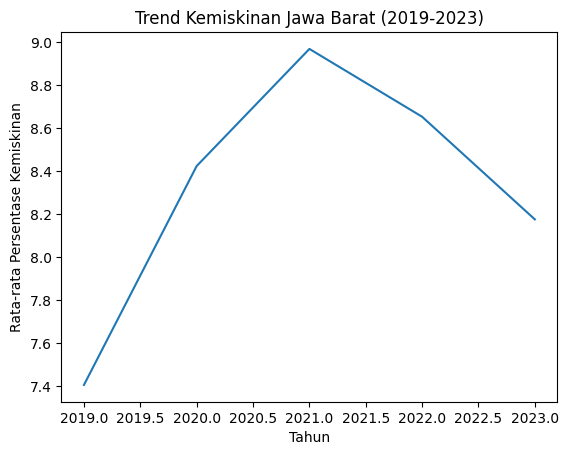

In [21]:
import matplotlib.pyplot as plt

avg = df_all.groupby("tahun")["persentase_miskin"].mean()

plt.figure()
plt.plot(avg.index, avg.values)
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Persentase Kemiskinan")
plt.title("Trend Kemiskinan Jawa Barat (2019-2023)")
plt.show()

In [22]:
df_all.groupby("tahun")["persentase_miskin"].mean()

tahun
2019    7.406667
2020    8.424815
2021    8.969630
2022    8.654074
2023    8.176667
Name: persentase_miskin, dtype: float64

In [23]:
df_2023 = df_all[df_all["tahun"] == 2023]

df_2023.sort_values("persentase_miskin", ascending=False).head(5)

,kabupaten,jumlah_miskin_ribu,persentase_miskin,tahun
126,Indramayu,214.74,12.13,2023
122,Kuningan,133.88,12.12,2023
140,Kota Tasikmalaya,79.37,11.53,2023
124,Majalengka,138.74,11.21,2023
123,Cirebon,249.18,11.20,2023


In [24]:
df_2023.sort_values("persentase_miskin").head(5)

,kabupaten,jumlah_miskin_ribu,persentase_miskin,tahun
138,Kota Depok,61.95,2.38,2023
135,Kota Bandung,102.80,3.96,2023
137,Kota Bekasi,129.40,4.10,2023
139,Kota Cimahi,28.56,4.66,2023
130,Bekasi,204.09,4.93,2023


In [25]:
df_all.to_csv("kemiskinan_clean.csv", index=False)